In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
import keras
from keras import layers

In [6]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))

**Comprehensive augmentation**

In [4]:
datagen = ImageDataGenerator(
    rotation_range=20,           # Rotate images up to 20 degrees
    width_shift_range=0.2,       # Shift horizontally by 20%
    height_shift_range=0.2,      # Shift vertically by 20%
    shear_range=0.2,             # Apply shearing transformation
    zoom_range=0.2,              # Zoom in/out by 20%
    horizontal_flip=True,        # Flip horizontally
    vertical_flip=False,         # Don't flip vertically (for most images)
    fill_mode='nearest',         # Fill pixels outside boundaries
    brightness_range=[0.8, 1.2], # Adjust brightness
    rescale=1./255               # Normalize pixel values
)

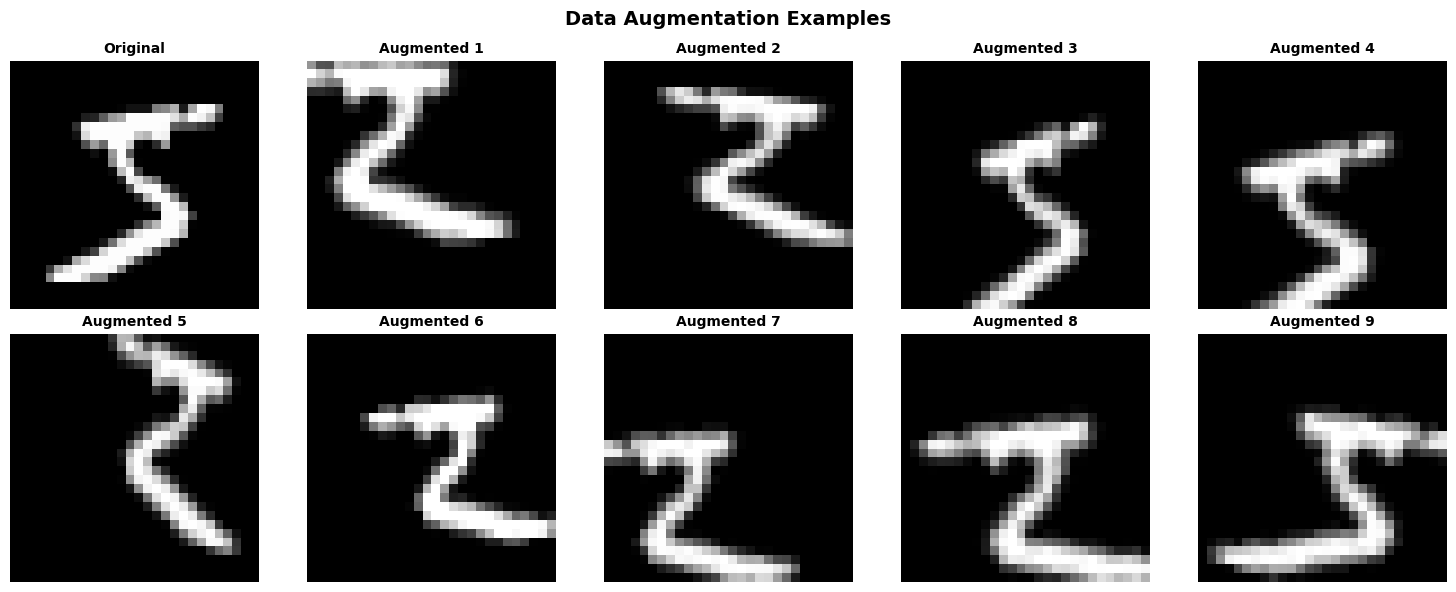

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# Original image
original = x_train[0]
axes[0].imshow(original, cmap='gray')
axes[0].set_title('Original', fontsize=10, fontweight='bold')
axes[0].axis('off')

# Generate augmented images
augmented = datagen.flow(np.expand_dims(original, 0), batch_size=1)
for i in range(1, 10):
    aug_img = next(augmented)[0].squeeze()
    axes[i].imshow(aug_img, cmap='gray')
    axes[i].set_title(f'Augmented {i}', fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Using Augmentation in Training**

- Method 1: Using ImageDataGenerator

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255.,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow(
    x_train, y_train,
    batch_size=32,
    subset='training'
)

val_generator = train_datagen.flow(
    x_train, y_train,
    batch_size=32,
    subset='validation'
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

- Method 2: Using layers (Keras 3+)

In [12]:
augmentation_layers = keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomFlip('horizontal'),
    layers.RandomZoom(0.1)
])

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    augmentation_layers
])

**Advanced Augmentation with Albumentations**

In [15]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

C:\Users\User\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
transform = A.Compose([
    A.Rotate(limit=20, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.CoarseDropout(max_holes=8, max_height=8, max_width=8, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

augmented = transform(image=image)['image']

C:\Users\User\AppData\Local\Temp\ipykernel_12948\4294083050.py:5: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
C:\Users\User\AppData\Local\Temp\ipykernel_12948\4294083050.py:6: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=8, max_width=8, p=0.3),
